<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week06_deutsch_jozsa_berstein_vazirani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The **Deutsch-Josza** (D-J) algorithm -- a generalization of the **Deutsch** algorithm -- is another foundational quantum algorithm first devised to better understand the type of problems that could be solved faster on a quantum computer. A few key things to keep in mind about the algorithm:

1.   As with the Deutsch algorithm, this is an algorithm conceived and analysed within the **query model of computation** -- roughly, what this means is we're given a quantum black box (called an oracle) that computes some function.
2. The algorithm can query the black box with any (valid) inputs, observe the respective outputs, but -- as the term black box indicates -- is **not** allowed to peek inside.
3. The objective is to *learn* the function with as few queries as possible. Indeed, within the query model, number of queries is the only measure of efficiency.
4. For the D-J algorithm, we know the following things about the function:
*   It implements a function $f:\{0,1\}^n\to \{0,1\}$, i.e. takes an $n$-bit binary string as input, spits out a $0$ or $1$ as output.

* The function is implemented using a quantum oracle $O_f:|x\rangle|y\rangle\mapsto |x\rangle|y\oplus f(x)\rangle$.

*   The additional function being implemented is either **constant** (i.e. all input strings output $0$ or all of them output $1$) or **balanced** (exactly half of the input strings output $1$.

5. The D-J algorithm tries to learn whether the black box $f$ is balanced or constant.

**Questions**:
1. Using a deterministic strategy, how many queries would one would need in the worst case?
2. Is there a randomized probabilistic strategy that would allow us to do better?

In [1]:
!pip install qiskit qiskit_aer
!pip install pylatexenc
!pip install numpy
from qiskit_aer import StatevectorSimulator, AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2b8f1960009776a91caebd4e65666776d0693310f728ca66c4eeaf0b5f98c44d
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In the next code cell, we will generate some examples of balanced functions, i.e. those that send exactly half of the inputs to output $0$ and the other half to output $1$. We will run the D-J circuit on each of these functions.

1. For constant functions, there's really only two options -- the $0$ function and the $1$ function.
2. For balanced functions, one strategy (but not the only one) to generate them is this: fix a randomly chosen bit position, and map each input to the bit in that position for that input.
- For example, if the position chosen is $2$, then the input string $1011$ gets mapped to $0$, while the input string $0110$ gets mapped to $1$.


In [2]:
#Constant oracle implementation

def deutsch_jozsa_oracle_constant(n, output_zero):
    oracle = QuantumCircuit(n+1)
    if not output_zero:
        oracle.x(n)  # Flip the output qubit for a constant-1 oracle
    return oracle
import random

#Random balanced oracle implementation

def random_balanced_oracle(n):
    """
    Creates a balanced oracle that outputs a randomly chosen input qubit.
    The function f(x) = x_i where i is chosen randomly.
    """
    oracle = QuantumCircuit(n + 1)

    # Randomly choose which input qubit to copy to output
    chosen_qubit = random.randint(0, n - 1)

    # Apply CNOT from chosen qubit to output
    oracle.cx(chosen_qubit, n)

    return oracle


The D-J circuit is implemented in the code cell below:

1.   The initial state is prepared with $n+1$ qubits, the first $n$ of which are initialized to $\left|0\right>$ and the last qubit initialized $\left|1\right>$.
2.   After a Hadamard gate is applied to each of the qubits, the algorithm makes (a grand total of) one query to the (not-so) black-box (for us). Another round of Hadamards later...
3. ...it knows exactly whether the function is balanced or constant. Let's see how!


In [3]:
def deutsch_jozsa_algorithm(n, oracle):
    dj_circuit = QuantumCircuit(n+1, n)

    # Step 1: Initialize output qubit to |1⟩
    dj_circuit.x(n)
    dj_circuit.barrier()
    # Step 2: Apply Hadamard to all qubits
    dj_circuit.h(range(n+1))
    dj_circuit.barrier()
    # Step 3: Apply the oracle
    dj_circuit.compose(oracle, inplace=True)
    dj_circuit.barrier()
    # Step 4: Apply Hadamard to input qubits again
    dj_circuit.h(range(n))

    # Step 5: Measure input qubits
    #dj_circuit.measure(range(n), range(n))
    dj_circuit.measure(range(n), range(n)[::-1])


    return dj_circuit

Let's create a D-J circuit each for the two constant oracles and two balanced oracles that we've defined above. We'll simulate them in a subsequent code cell, and observe the measurement outcomes in each case.

In [4]:
n=5
dj_circuitC0=deutsch_jozsa_algorithm(n, deutsch_jozsa_oracle_constant(n, output_zero=True))
dj_circuitC1=deutsch_jozsa_algorithm(n, deutsch_jozsa_oracle_constant(n, output_zero=False))
dj_circuitB0=deutsch_jozsa_algorithm(n, random_balanced_oracle(n))

Here's how the respective circuits look like.

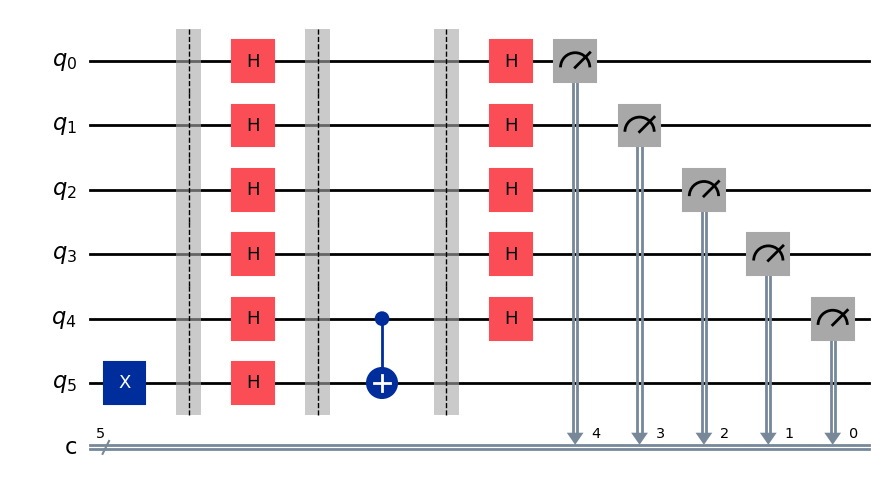

In [13]:
dj_circuitB0.draw(output="mpl") # random balanced
#dj_circuitC0.draw(output="mpl") # constant 0
#dj_circuitC1.draw(output="mpl") # constant 1

We now prepare a backend to simulate this circuit to observe its measurement distribution. We will observe measurement outcomes for both **constant** oracles and the **balanced** oracle. We use the state vector simulation method.

Result: {'00001': 5000}


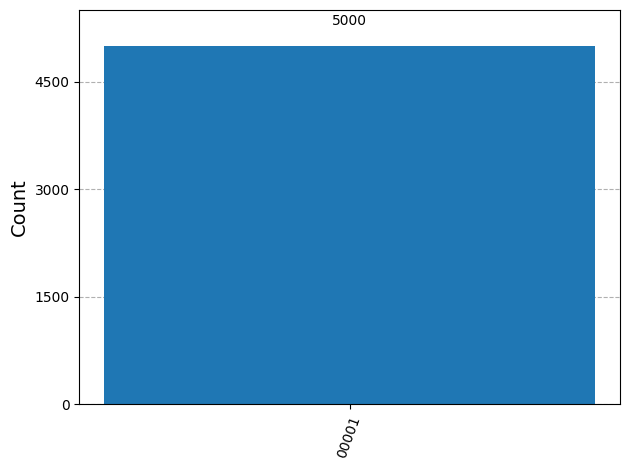

In [14]:
backend = StatevectorSimulator()
# Transpile the circuit for the backend
transpiled_circuit = transpile(dj_circuitB0, backend)
# Execute the transpiled circuit using the backend's run method
job = backend.run(transpiled_circuit, shots=5000)
# Retrieve the results from the job
result = job.result()
# Get counts of each outcome
counts = result.get_counts()
# Visualization
print("Result:", counts)
plot_histogram(counts)

**Bernstein--Vazirani** Algorithm: Let $f:\{0,1\}^n\to \{0,1\}$ be a Boolean function with the promise that $$f(x)=a\cdot x \oplus b,$$ where:
1. $a\in \{0,1\}^n$ an unknown $n$-bit string.
2. $b\in \{0,1\}$
3. $a\cdot x$ is the $\text{mod}-2$ inner product

**Classical Strategy**: In the worst case, how many queries to $f$ are required to determine $a$?

**Quantum Strategy**: Using the Deutsch--Jozsa circuit, how can we determine $a$ using a a single query to the oracle $O_f$ implementing $f$?

In [15]:
def bernstein_vazirani_oracle(n, a, b=0):
    """
    Oracle for f(x) = a·x XOR b, with O_f: |x>|y> -> |x>|y XOR f(x)>.
    Args:
        n (int): number of input qubits
        a (str | list[int]): n-bit string/list representing hidden string a
                             e.g. "1011" or [1,0,1,1]
        b (int): bit in {0,1}
    Returns:
        QuantumCircuit: (n+1)-qubit oracle circuit
    """
    # Normalize a to a list of ints length n
    if isinstance(a, str):
        a_bits = [int(ch) for ch in a]
    else:
        a_bits = list(a)

    if len(a_bits) != n:
        raise ValueError(f"'a' must have length n={n}, got {len(a_bits)}")
    if b not in (0, 1):
        raise ValueError("'b' must be 0 or 1")

    oracle = QuantumCircuit(n + 1, name="O_f")

    # Compute y -> y XOR (a·x)
    for i, bit in enumerate(a_bits):
        if bit == 1:
            oracle.cx(i, n)
    # Add the affine offset b
    if b == 1:
        oracle.x(n)
    return oracle

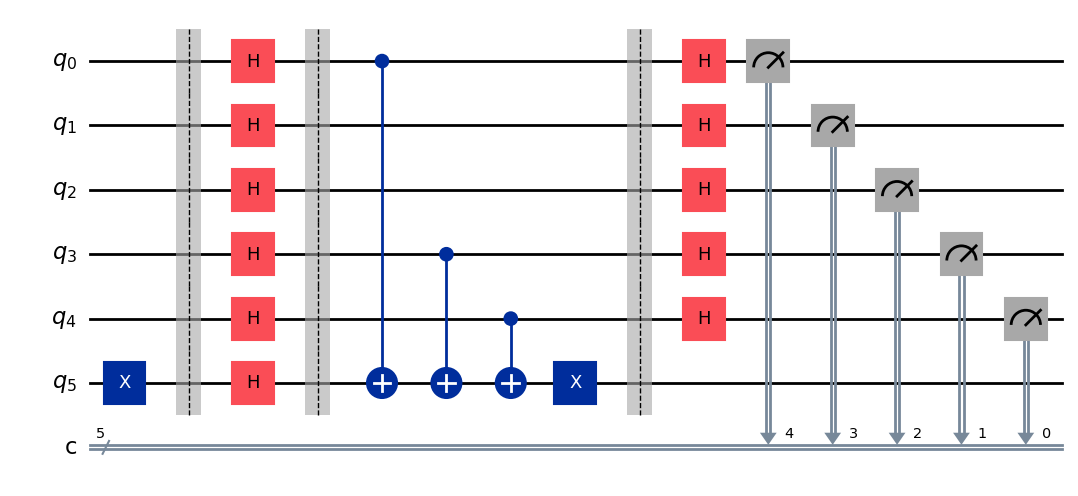

In [16]:
n = 5
bz_oracle = bernstein_vazirani_oracle(n, [1,0,0,1,1], b=1)
bz_circuit=deutsch_jozsa_algorithm(n, bz_oracle)
bz_circuit.draw(output="mpl")

Result: {'10011': 5000}


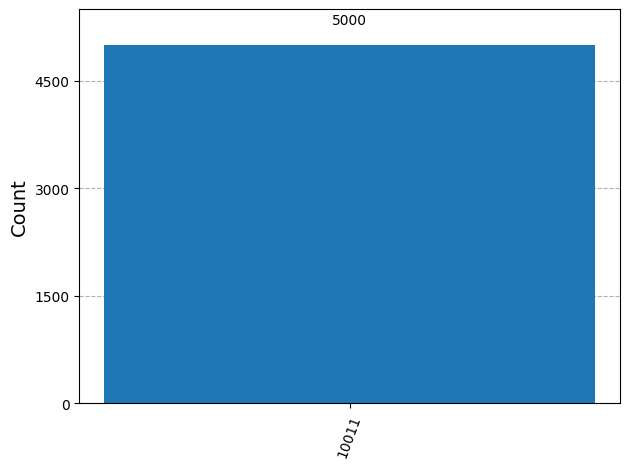

In [17]:
backend = StatevectorSimulator()
# Transpile the circuit for the backend
transpiled_circuit = transpile(bz_circuit, backend)
# Execute the transpiled circuit using the backend's run method
job = backend.run(transpiled_circuit, shots=5000)
# Retrieve the results from the job
result = job.result()
# Get counts of each outcome
counts = result.get_counts()
# Visualization
print("Result:", counts)
plot_histogram(counts)